# (25) deep dec — tiny imgnet

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('ImageNet32', model_type, 'ngd|deep')

t_train = 32

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1 # 1/8 * t_train

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 8

cfg_tr['batch_size'] = 50
cfg_tr['epochs'] = 10

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

256230

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  661.0 K   |
|     ———     |    ———     |
|    layer    |  661.0 K   |
+-------------+------------+

poisson_ImageNet32_t-32_b-1_kms-(256,8,1)_<ngd|deep>
b50-ep10-lr(0.0002)_temp(0.05)_gr(4000)_(2025_07_28,01:00)

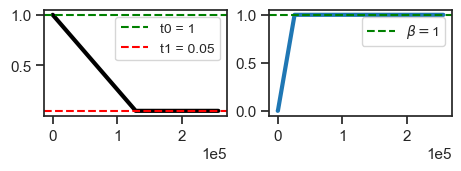

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(256, 8, 8), input_sz=(3, 32, 32), temp=1)

In [8]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 256, 1, 1]), torch.Size([1, 256, 1, 1]))

In [9]:
tr.model.cfg.set_clamp_val('u', 5.0)
tr.model.cfg.set_clamp_val('du', 5.0)

tr.model.cfg.clamp_vals

{'u': (5.0,), 'du': (5.0,), 'dec': 3.45}

In [10]:
tr.train('expand=1_no-se')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 10, avg loss: 69.941: 100%|███████| 10/10 [69:09:14<00:00, 24895.48s/it]


100%|███████████████████████████████████| 5/5 [00:39<00:00,  7.96s/it]


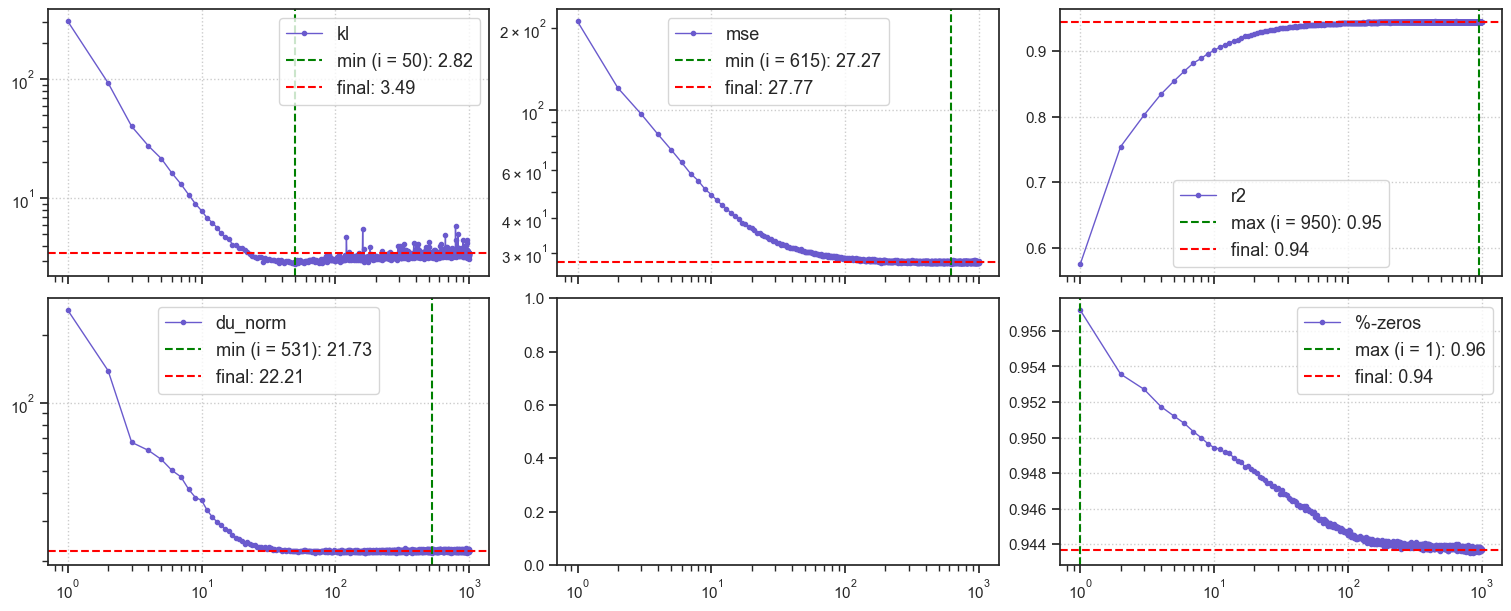

CPU times: user 45.6 s, sys: 4.71 s, total: 50.3 s
Wall time: 50.2 s


In [11]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='slateblue')

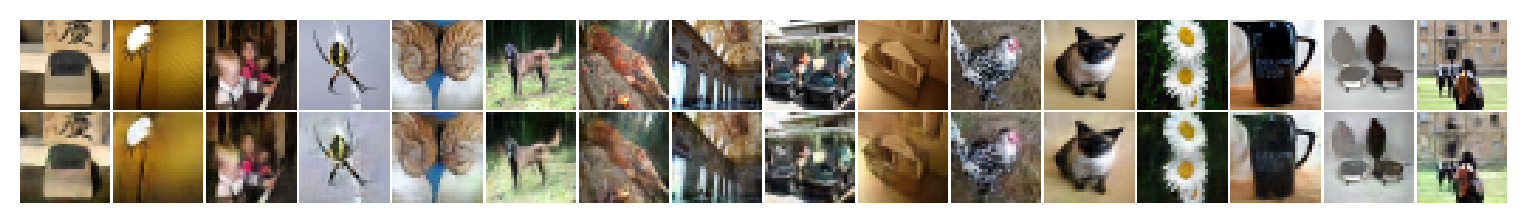

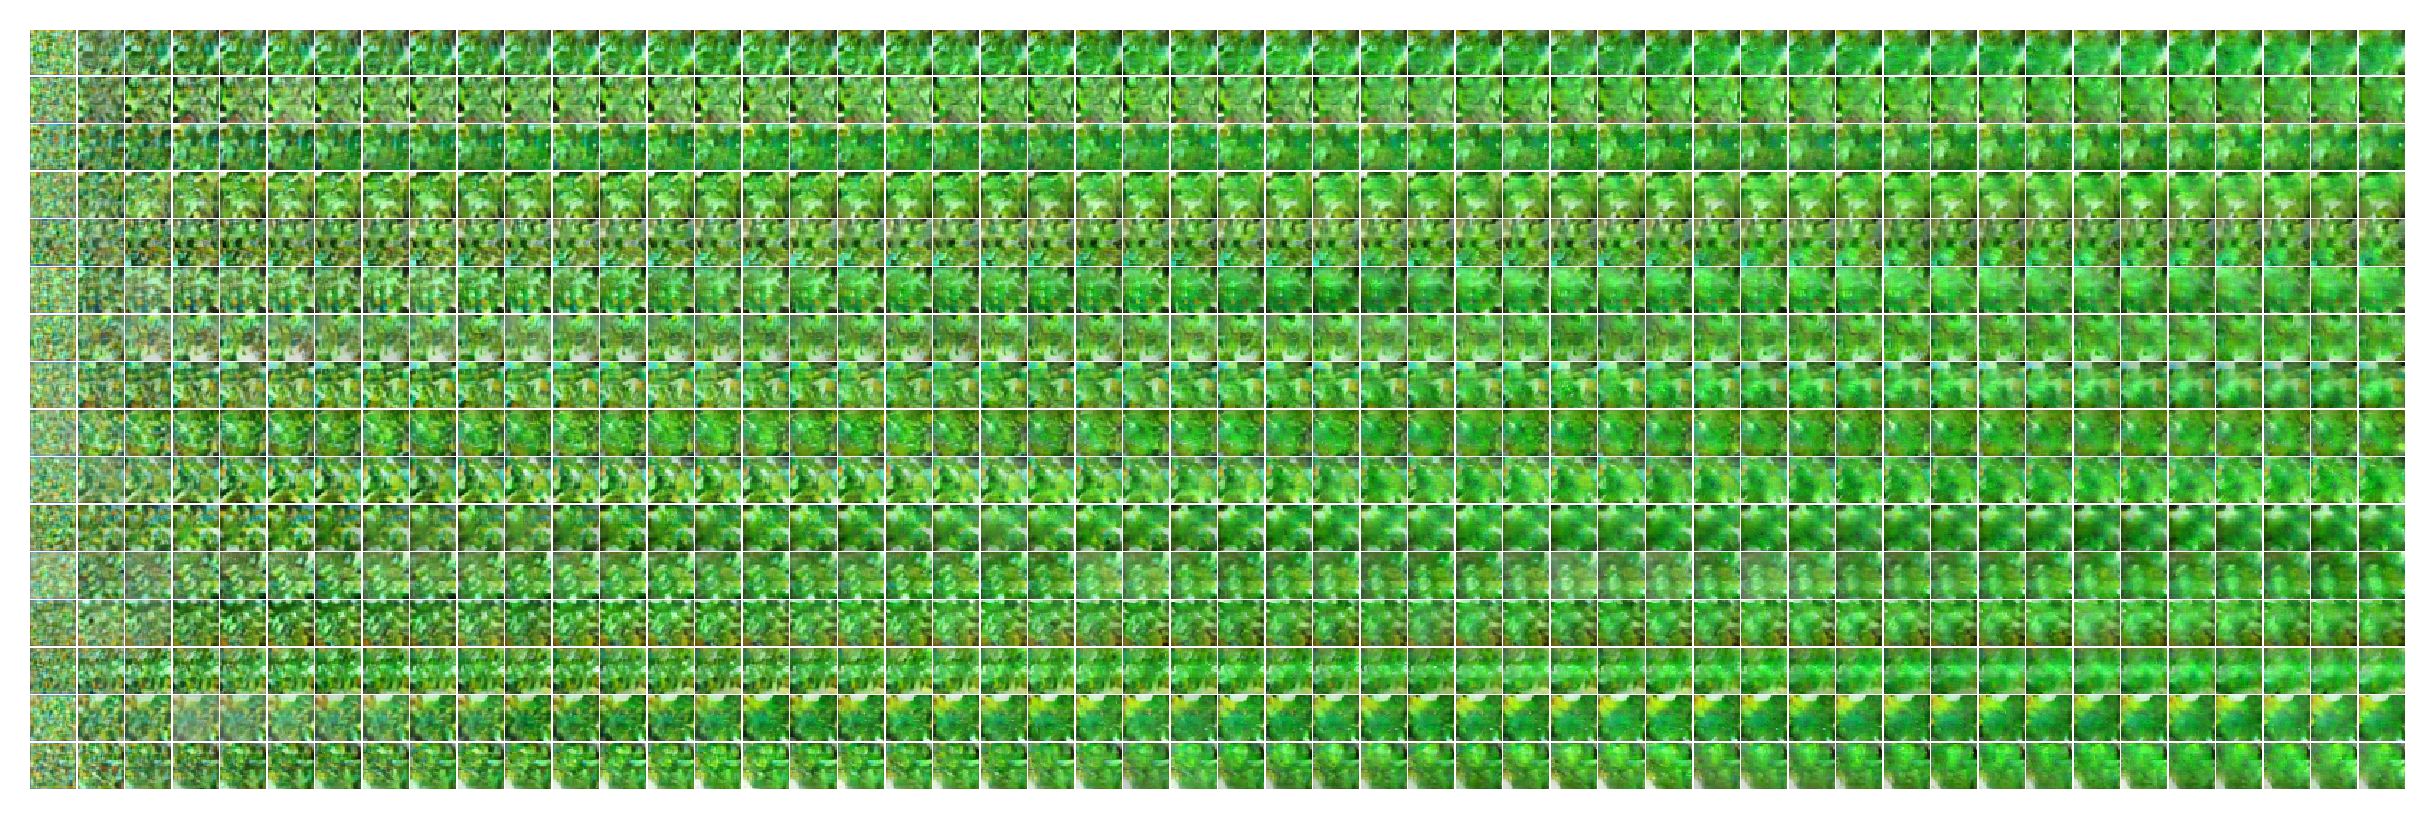

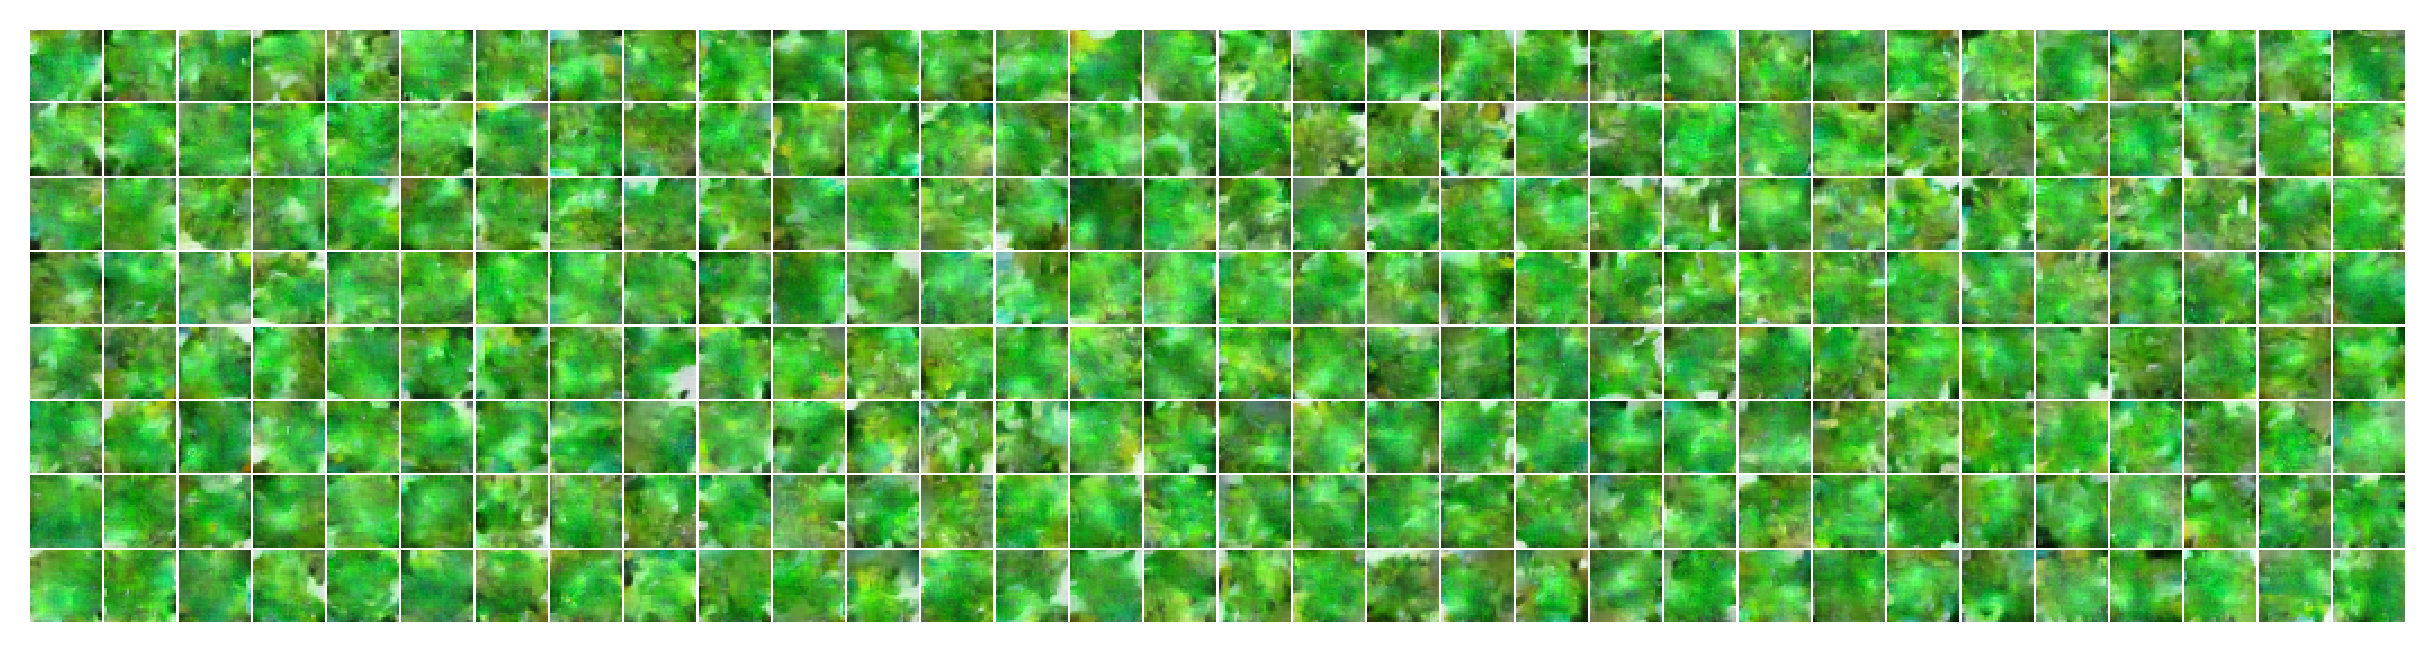

In [12]:
tr.show_recon();
tr.show_samples();

In [13]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(256,)

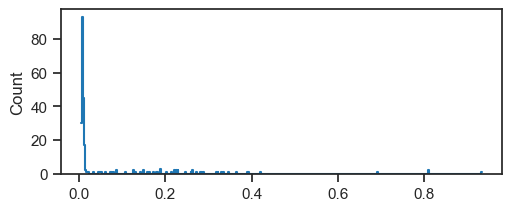

In [14]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

In [15]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(256,)

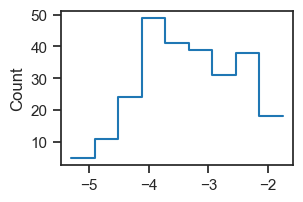

In [16]:
histplot(u0.ravel())
plt.show()

In [17]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=0.5050936501776583, pvalue=5.570512491716218e-18)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']